In [ ]:
#########################################################################
########------ Ciencia de Datos e IA Generativa con Python ------########
#########################################################################
# Capacitador: Julio César Bernal Fernández
# email: juliobf08@gmail.com
# Tema : Aplicación de Clustering (Agrupamiento)
# versión: 1.0
#########################################################################

In [1]:
# Manipulación y tratatamiendo de los datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# sistema operativo
import warnings
import os

# Modelos de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics

#Librerías Aprendizaje No Supervisado
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
pwd

'/content'

In [4]:
df =pd.read_excel('Empresas_Reactiva_Peru.xlsx')
#df = pd.DataFrame(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71553 entries, 0 to 71552
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RUC              71553 non-null  float64
 1   NOMBRE_EMPRESA   71553 non-null  object 
 2   SECTOR           71553 non-null  object 
 3   BANCO            71553 non-null  object 
 4   MONTO_PRESTAMO   71553 non-null  float64
 5   FLG_1MM          71553 non-null  int64  
 6   MONTO_COBERTURA  71553 non-null  float64
 7   DEPARTAMENTO     71553 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 4.4+ MB


In [5]:
df.head()

,RUC,NOMBRE_EMPRESA,SECTOR,BANCO,MONTO_PRESTAMO,FLG_1MM,MONTO_COBERTURA,DEPARTAMENTO
0,2.052055e+10,1 ONE S.A.C.,COMERCIO,CRÉDITO,1894383.0,1,1704944.7,LIMA
1,2.054319e+10,1000 MILLAS SAC,COMERCIO,CRÉDITO,300570.0,0,270513.0,LIMA
2,2.037972e+10,100PRE FELIZ SAC,"AGRICULTUR, GANADERIA, CAZA Y SILVICULTURA",BANCO BBVA PERU,1370000.0,1,1233000.0,LIMA
3,2.060266e+10,1010 SAC,INDUSTRIA MANUFACTURERA,CRÉDITO,600918.0,0,540826.2,LIMA
4,2.060146e+10,105 EMERGENCIAS Y SOLUCIONES AQP E.I.R.L.,COMERCIO,CRÉDITO,6350.0,0,6223.0,AREQUIPA


In [6]:
df.shape

(71553, 8)

In [7]:
df1 = pd.read_excel('Income.xlsx')
#df1 = pd.DataFrame(df1)
#df1.head(n=10)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71556 entries, 0 to 71555
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RUC     71553 non-null  float64
 1   INCOME  71553 non-null  float64
dtypes: float64(2)
memory usage: 1.1 MB


In [8]:
df1.head()

,RUC,INCOME
0,2.052055e+10,5.903929e+08
1,2.054319e+10,9.367398e+07
2,2.037972e+10,1.701463e+07
3,2.060266e+10,1.153865e+08
4,2.060146e+10,1.979006e+06


In [9]:
df2 = pd.merge(df, df1, on='RUC')

In [16]:
df2.head()

,RUC,NOMBRE_EMPRESA,SECTOR,BANCO,MONTO_PRESTAMO,FLG_1MM,MONTO_COBERTURA,DEPARTAMENTO,INCOME
0,20520549740.00,1 ONE S.A.C.,COMERCIO,CRÉDITO,1894383.00,1,1704944.70,LIMA,590392875.16
1,20543190617.00,1000 MILLAS SAC,COMERCIO,CRÉDITO,300570.00,0,270513.00,LIMA,93673975.37
2,20379719440.00,100PRE FELIZ SAC,"AGRICULTUR, GANADERIA, CAZA Y SILVICULTURA",BANCO BBVA PERU,1370000.00,1,1233000.00,LIMA,17014629.00
3,20602664091.00,1010 SAC,INDUSTRIA MANUFACTURERA,CRÉDITO,600918.00,0,540826.20,LIMA,115386453.60
4,20601455375.00,105 EMERGENCIAS Y SOLUCIONES AQP E.I.R.L.,COMERCIO,CRÉDITO,6350.00,0,6223.00,AREQUIPA,1979005.70


In [15]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [17]:
#CREAMOS EL % DE COBERTURA:

df2['PORCENTAJE_COBERTURA'] = df2['MONTO_COBERTURA'] / df2['MONTO_PRESTAMO']

In [18]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71555 entries, 0 to 71554
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   RUC                   71555 non-null  float64
 1   NOMBRE_EMPRESA        71555 non-null  object 
 2   SECTOR                71555 non-null  object 
 3   BANCO                 71555 non-null  object 
 4   MONTO_PRESTAMO        71555 non-null  float64
 5   FLG_1MM               71555 non-null  int64  
 6   MONTO_COBERTURA       71555 non-null  float64
 7   DEPARTAMENTO          71555 non-null  object 
 8   INCOME                71555 non-null  float64
 9   PORCENTAJE_COBERTURA  71555 non-null  float64
dtypes: float64(5), int64(1), object(4)
memory usage: 5.5+ MB


In [19]:
df2.head()

,RUC,NOMBRE_EMPRESA,SECTOR,BANCO,MONTO_PRESTAMO,FLG_1MM,MONTO_COBERTURA,DEPARTAMENTO,INCOME,PORCENTAJE_COBERTURA
0,20520549740.00,1 ONE S.A.C.,COMERCIO,CRÉDITO,1894383.00,1,1704944.70,LIMA,590392875.16,0.90
1,20543190617.00,1000 MILLAS SAC,COMERCIO,CRÉDITO,300570.00,0,270513.00,LIMA,93673975.37,0.90
2,20379719440.00,100PRE FELIZ SAC,"AGRICULTUR, GANADERIA, CAZA Y SILVICULTURA",BANCO BBVA PERU,1370000.00,1,1233000.00,LIMA,17014629.00,0.90
3,20602664091.00,1010 SAC,INDUSTRIA MANUFACTURERA,CRÉDITO,600918.00,0,540826.20,LIMA,115386453.60,0.90
4,20601455375.00,105 EMERGENCIAS Y SOLUCIONES AQP E.I.R.L.,COMERCIO,CRÉDITO,6350.00,0,6223.00,AREQUIPA,1979005.70,0.98


In [20]:
corr = df2[['MONTO_PRESTAMO','MONTO_COBERTURA','INCOME','PORCENTAJE_COBERTURA']].corr().round(3)
corr

,MONTO_PRESTAMO,MONTO_COBERTURA,INCOME,PORCENTAJE_COBERTURA
MONTO_PRESTAMO,1.00,1.00,0.56,-0.73
MONTO_COBERTURA,1.00,1.00,0.57,-0.74
INCOME,0.56,0.57,1.00,-0.48
PORCENTAJE_COBERTURA,-0.73,-0.74,-0.48,1.00


In [21]:
X=np.array(df2[['PORCENTAJE_COBERTURA','MONTO_PRESTAMO','INCOME']])
X.shape

(71555, 3)

Pasos a seguir para clusterizar un caso de uso:

1.- Identificar las variables numéricas que van a ser tomadas en cuenta (no flags, no variables de texto, no variables de identificación, entre otras)

2.- Podemos revisar la posibilidad de añadir o crear nuevas variables numéricas que tengan sentido o coherencia en el análisis

3.- Validar la correlación de variables para determinar cuáles deben ser elegidas en la clusterización.

4.- Elegir las variables numéricas que se tomarán en cuenta en el análisis.

5.- Iterar el algoritmo en un rango de opciones y en base al resultado y nuestro criterio, determinar el número de cluster.

6.- Aplicar el algoritmo KMeans y generar los cluster para todos los registros de la tabla.

6.- Almacenar los cluster en un dataframe y concatenarlos con los registros originales.

7.- Exportar la base de datos con la etiqueta de clúster para los análisis correspondientes.

[KMeans(n_clusters=1), KMeans(n_clusters=2), KMeans(n_clusters=3), KMeans(n_clusters=4), KMeans(n_clusters=5), KMeans(n_clusters=6), KMeans(n_clusters=7), KMeans(), KMeans(n_clusters=9)]
[2.5167509352941434e+21, 9.960957531812584e+20, 5.4103173482564085e+20, 3.789507010659929e+20, 2.5337059435469026e+20, 1.5378882987749897e+20, 1.0891711355334858e+20, 8.80580525453086e+19, 6.197513735031688e+19]


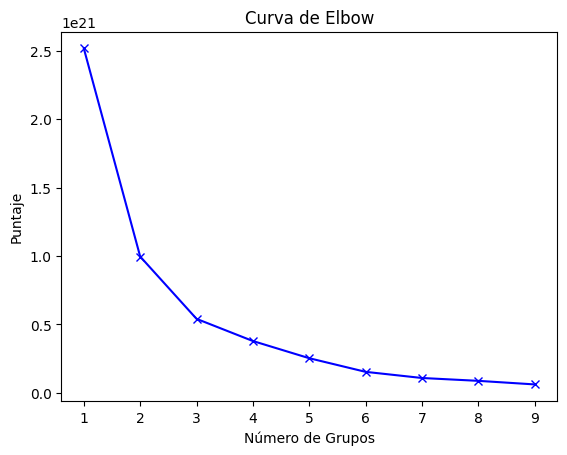

In [24]:
Nc = range(1,10)
kmeans = [KMeans(n_clusters=i) for i in Nc]
print(kmeans)
score = [kmeans[i].fit(X).inertia_ for i in range(len(kmeans))]
print(score)

plt.plot(Nc,score, 'bx-')
plt.xlabel('Número de Grupos')
plt.ylabel('Puntaje')
plt.title('Curva de Elbow')
plt.show()

In [25]:
num_clusters = 4

In [26]:
data=df2[['PORCENTAJE_COBERTURA','MONTO_PRESTAMO','INCOME']]

In [27]:
#Segmentación de KMeans
kmeans = KMeans(init='k-means++', n_clusters=num_clusters, n_init=10)
kmeans.fit(data)

KMeans(n_clusters=4, n_init=10)

In [28]:
pd.DataFrame(kmeans.predict(data)).value_counts()

,count
0,
0,67888
3,3110
1,457
2,100


In [29]:
#from sklearn.metrics import silhouette_score

In [30]:
#def form_cluster(x,k):
 #   no_clusters = k
  #  model = KMeans(n_clusters=no_clusters,init='k-means++', n_init=10,random_state = 123 )
   # model.fit(x)
    #labels = model.labels_
    #print(labels)
    # Cacluate the silhouette score
    #sh_score = silhouette_score(x,labels)
    #print(sh_score)
    #return sh_score

In [31]:
prediction = kmeans.predict(data)

In [37]:
prediction

array([3, 0, 0, ..., 0, 3, 0], dtype=int32)

In [34]:
#form_cluster(data,4)

In [ ]:
#form_cluster(data,5)

In [ ]:
#model = KMeans(n_clusters=4,init='k-means++', n_init=10,random_state = 123 )
#model.fit(X)

In [ ]:
#prediction= model.predict(X)

In [38]:
prediction

array([3, 0, 0, ..., 0, 3, 0], dtype=int32)

In [39]:
pronosseg = pd.DataFrame(prediction)

In [40]:
pronosseg.columns=['Segmento']

In [44]:
pronosseg.head(20)

,Segmento
0,3
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [43]:
pronosseg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71555 entries, 0 to 71554
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Segmento  71555 non-null  int32
dtypes: int32(1)
memory usage: 279.6 KB


In [45]:
data = data[['MONTO_PRESTAMO','INCOME','PORCENTAJE_COBERTURA']]
data.head()

,MONTO_PRESTAMO,INCOME,PORCENTAJE_COBERTURA
0,1894383.00,590392875.16,0.90
1,300570.00,93673975.37,0.90
2,1370000.00,17014629.00,0.90
3,600918.00,115386453.60,0.90
4,6350.00,1979005.70,0.98


In [46]:
res1=pd.concat([data,pronosseg],axis=1).groupby(['Segmento']).mean()
#res1.style.applymap(lambda x: 'background-color : yellow' if x>res1.iloc[0,0] else '')
res1

,MONTO_PRESTAMO,INCOME,PORCENTAJE_COBERTURA
Segmento,,,
0,230219.19,23427614.12,0.95
1,5350686.17,1321159188.79,0.86
2,9180699.73,3381509479.17,0.80
3,1850980.27,346892082.43,0.89


In [47]:
pronosseg.head()

,Segmento
0,3
1,0
2,0
3,0
4,0


In [48]:
data_final=pd.concat([df2,pronosseg],axis=1)

In [49]:
data_final.head()

,RUC,NOMBRE_EMPRESA,SECTOR,BANCO,MONTO_PRESTAMO,FLG_1MM,MONTO_COBERTURA,DEPARTAMENTO,INCOME,PORCENTAJE_COBERTURA,Segmento
0,20520549740.00,1 ONE S.A.C.,COMERCIO,CRÉDITO,1894383.00,1,1704944.70,LIMA,590392875.16,0.90,3
1,20543190617.00,1000 MILLAS SAC,COMERCIO,CRÉDITO,300570.00,0,270513.00,LIMA,93673975.37,0.90,0
2,20379719440.00,100PRE FELIZ SAC,"AGRICULTUR, GANADERIA, CAZA Y SILVICULTURA",BANCO BBVA PERU,1370000.00,1,1233000.00,LIMA,17014629.00,0.90,0
3,20602664091.00,1010 SAC,INDUSTRIA MANUFACTURERA,CRÉDITO,600918.00,0,540826.20,LIMA,115386453.60,0.90,0
4,20601455375.00,105 EMERGENCIAS Y SOLUCIONES AQP E.I.R.L.,COMERCIO,CRÉDITO,6350.00,0,6223.00,AREQUIPA,1979005.70,0.98,0


In [50]:
data_final['Segmento'].value_counts()

,count
Segmento,
0,67888
3,3110
1,457
2,100


In [ ]:
#EXPORTAR BASE

data_final.to_csv("resultados_test.csv",index=False, sep = '|')

In [51]:
data_final.to_excel("resultados_test_1.xlsx",index=False)